In [ ]:
pip install tensorflow


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from tensorflow.keras.datasets import mnist
(x_train, _), (_, _) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
# Load and preprocess data
# ==============================
(x_train, _), (_, _) = mnist.load_data()
x_train = x_train / 127.5 - 1.0  # Normalize to [-1, 1]
x_train = x_train.reshape(-1, 28, 28, 1)
print(x_train.shape)

BUFFER_SIZE = 60000
BATCH_SIZE = 256
train_dataset = tf.data.Dataset.from_tensor_slices(x_train).shuffle(BUFFER_SIZE).batch(BATCH_SIZE)

(60000, 28, 28, 1)


In [ ]:
print(x_train.shape)

(60000, 28, 28, 1)


In [ ]:
# ==============================
# Generator
# ==============================
generator = tf.keras.Sequential([
    tf.keras.layers.Dense(7 * 7 * 256, use_bias=False, input_shape=(100,)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.LeakyReLU(),

    tf.keras.layers.Reshape((7, 7, 256)),
    tf.keras.layers.Conv2DTranspose(128, (5, 5), strides=(1, 1), padding='same', use_bias=False),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.LeakyReLU(),

    tf.keras.layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.LeakyReLU(),

    tf.keras.layers.Conv2DTranspose(1, (5, 5), strides=(2, 2), padding='same', use_bias=False, activation='tanh')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# ==============================
# Discriminator
# ==============================
discriminator = tf.keras.Sequential([
    tf.keras.layers.Conv2D(64, (5, 5), strides=(2, 2), padding='same', input_shape=[28, 28, 1]),
    tf.keras.layers.LeakyReLU(),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same'),
    tf.keras.layers.LeakyReLU(),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# ==============================
# Loss and Optimizers
# ==============================
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=False)
generator_optimizer = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)

# ==============================
# Loss functions
# ==============================
def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

In [ ]:
#@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, 100])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)

        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

    return gen_loss, disc_loss

In [ ]:
# Training loop
# ==============================
EPOCHS = 50
noise_dim = 100
num_examples_to_generate = 16

seed = tf.random.normal([num_examples_to_generate, noise_dim])

def generate_and_save_images(model, epoch, test_input):
    predictions = model(test_input, training=False)
    fig = plt.figure(figsize=(4,4))

    for i in range(predictions.shape[0]):
        plt.subplot(4, 4, i+1)
        plt.imshow((predictions[i, :, :, 0] + 1) / 2, cmap='gray')  # Convert from [-1,1] to [0,1]
        plt.axis('off')

    plt.suptitle(f'Epoch {epoch}', fontsize=12)
    plt.show()

def train(dataset, epochs):
    for epoch in range(epochs):
        for image_batch in dataset:
            gen_loss, disc_loss = train_step(image_batch)

        print(f'Epoch {epoch+1}, Gen Loss: {gen_loss:.4f}, Disc Loss: {disc_loss:.4f}')
        generate_and_save_images(generator, epoch + 1, seed)

Epoch 1, Gen Loss: 0.9299, Disc Loss: 1.1671


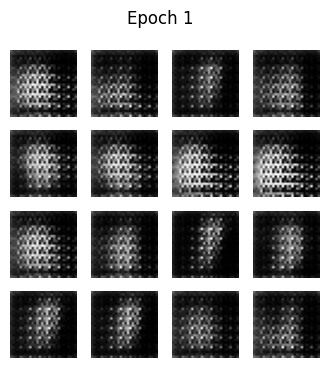

Epoch 2, Gen Loss: 0.9413, Disc Loss: 1.1838


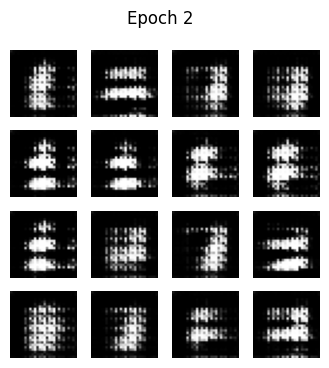

Epoch 3, Gen Loss: 0.7655, Disc Loss: 1.3673


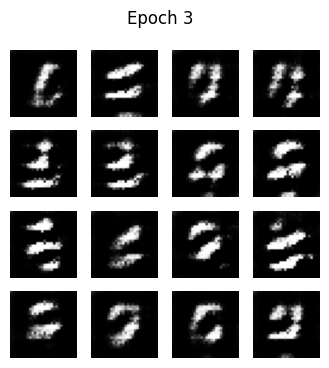

Epoch 4, Gen Loss: 0.9857, Disc Loss: 1.0872


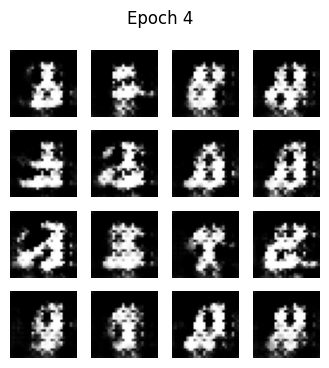

Epoch 5, Gen Loss: 0.9321, Disc Loss: 1.1613


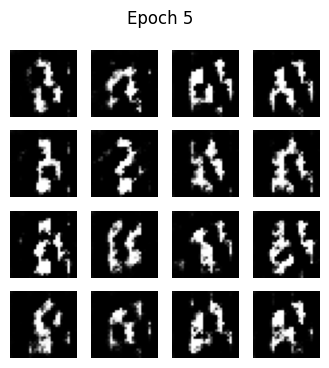

Epoch 6, Gen Loss: 0.7403, Disc Loss: 1.4327


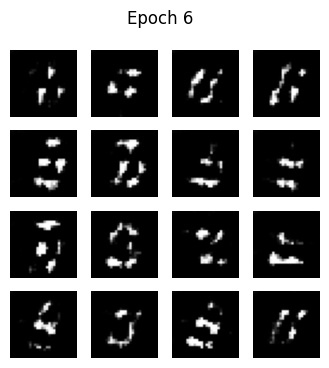

Epoch 7, Gen Loss: 0.9841, Disc Loss: 1.1789


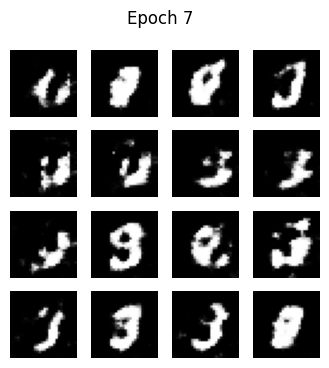

Epoch 8, Gen Loss: 1.1020, Disc Loss: 1.3006


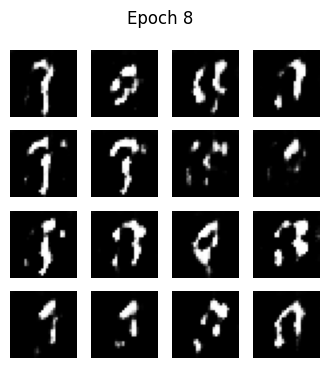

Epoch 9, Gen Loss: 1.0809, Disc Loss: 1.0232


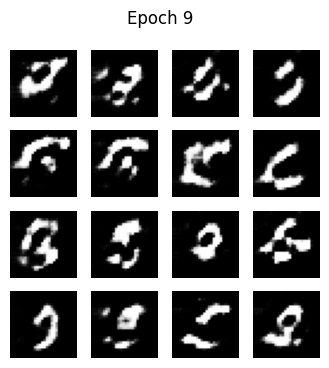

Epoch 10, Gen Loss: 0.9268, Disc Loss: 1.2407


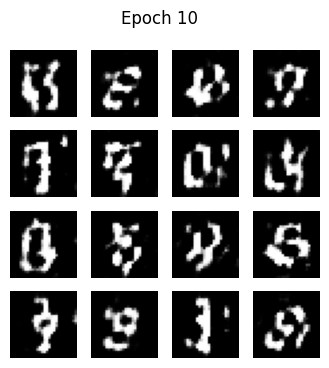

Epoch 11, Gen Loss: 1.2957, Disc Loss: 0.8229


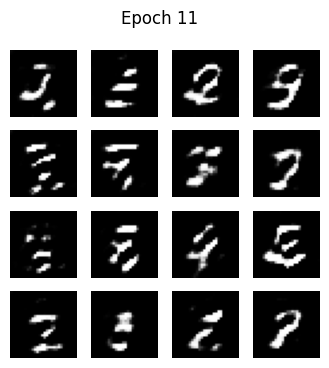

Epoch 12, Gen Loss: 0.8645, Disc Loss: 1.4915


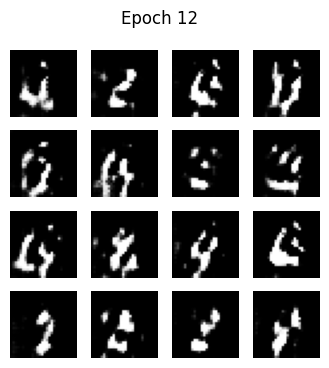

Epoch 13, Gen Loss: 1.0795, Disc Loss: 1.0805


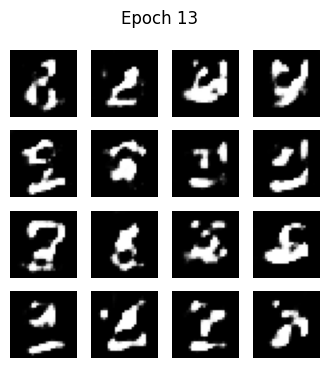

Epoch 14, Gen Loss: 1.3190, Disc Loss: 0.8798


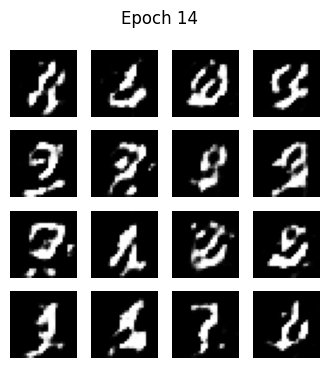

Epoch 15, Gen Loss: 1.0162, Disc Loss: 1.3123


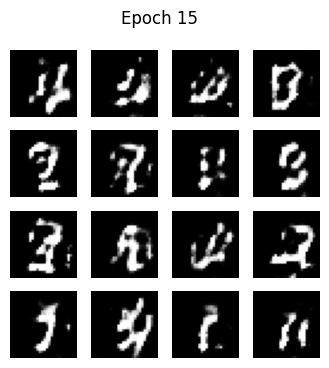

Epoch 16, Gen Loss: 1.0158, Disc Loss: 1.2126


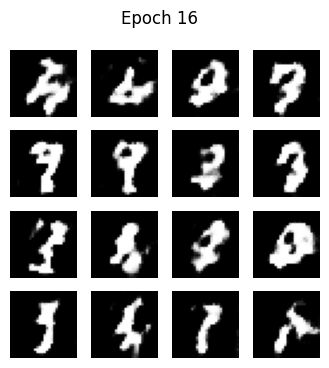

Epoch 17, Gen Loss: 1.4113, Disc Loss: 0.8976


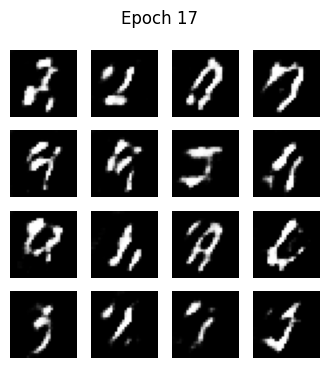

Epoch 18, Gen Loss: 1.1256, Disc Loss: 1.0423


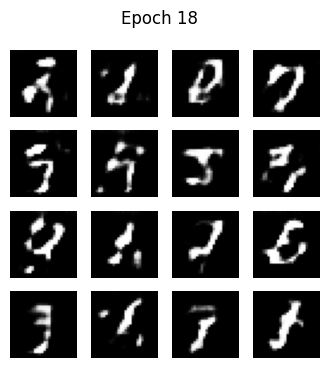

Epoch 19, Gen Loss: 1.2980, Disc Loss: 1.0524


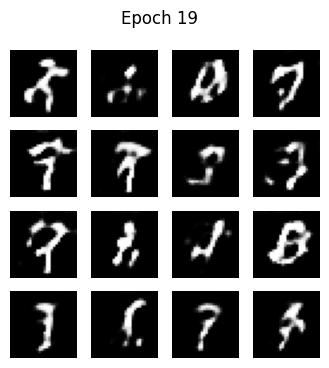

Epoch 20, Gen Loss: 1.1977, Disc Loss: 1.1186


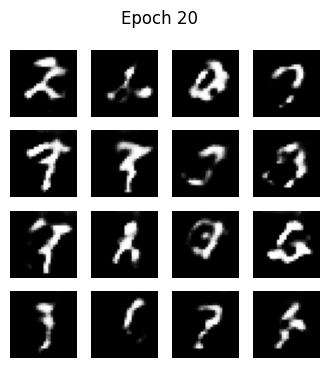

Epoch 21, Gen Loss: 1.2748, Disc Loss: 1.2858


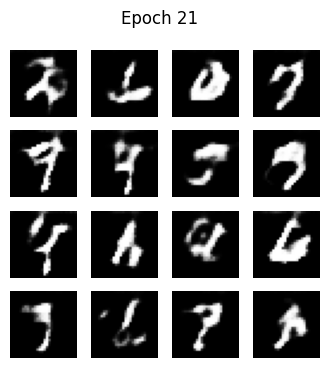

Epoch 22, Gen Loss: 1.1849, Disc Loss: 0.9130


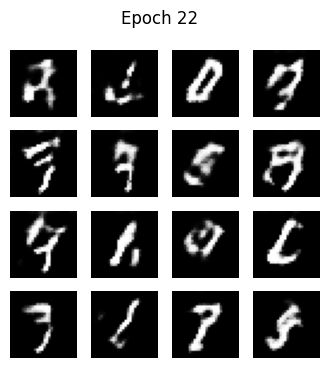

Epoch 23, Gen Loss: 1.3908, Disc Loss: 1.1040


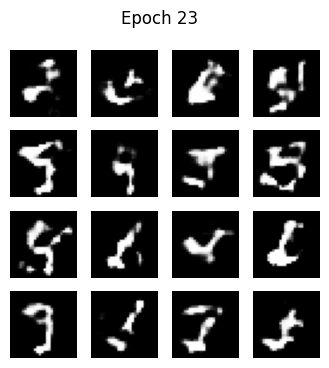

Epoch 24, Gen Loss: 1.2642, Disc Loss: 0.9155


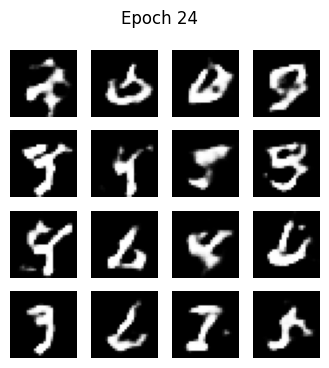

Epoch 25, Gen Loss: 1.3143, Disc Loss: 0.8346


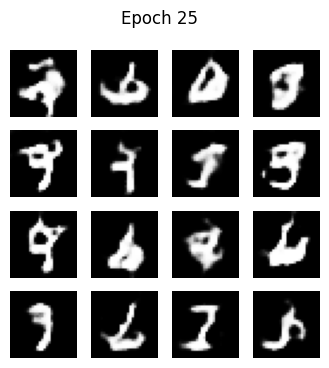

Epoch 26, Gen Loss: 1.1632, Disc Loss: 0.9855


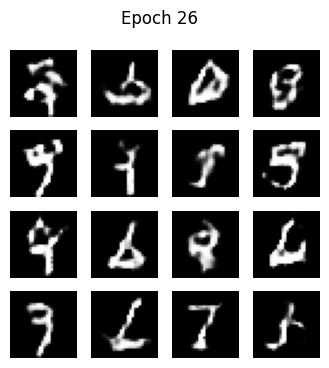

Epoch 27, Gen Loss: 0.9731, Disc Loss: 1.2407


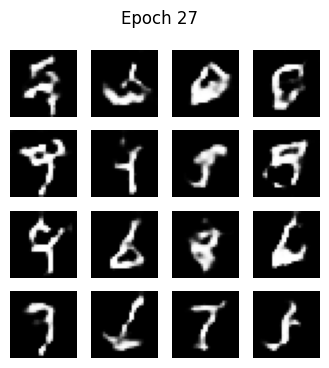

Epoch 28, Gen Loss: 1.0466, Disc Loss: 1.1951


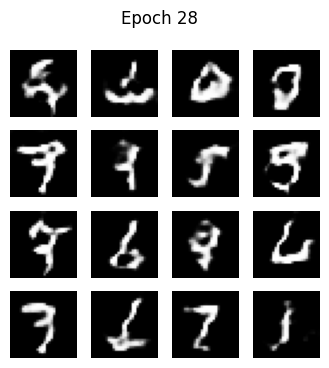

Epoch 29, Gen Loss: 1.3601, Disc Loss: 1.0638


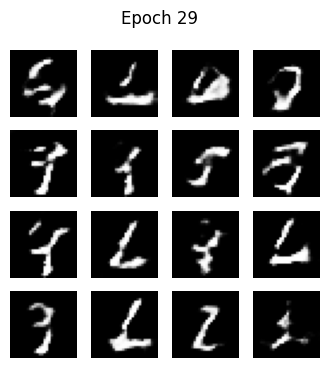

Epoch 30, Gen Loss: 1.2735, Disc Loss: 0.9125


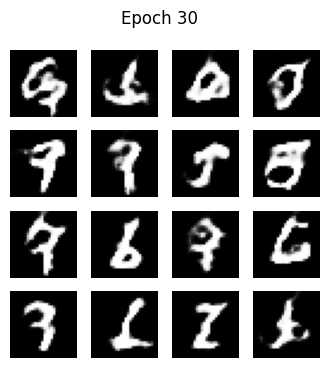

Epoch 31, Gen Loss: 1.0719, Disc Loss: 1.0486


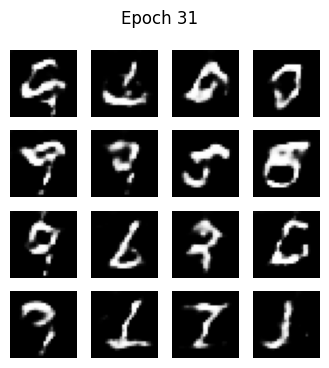

Epoch 32, Gen Loss: 1.1128, Disc Loss: 1.1698


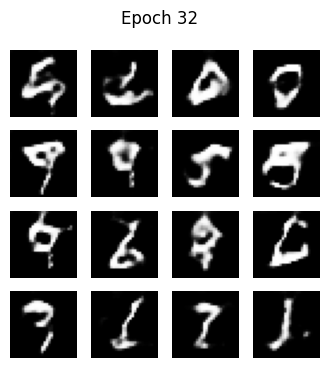

Epoch 33, Gen Loss: 1.0925, Disc Loss: 1.2175


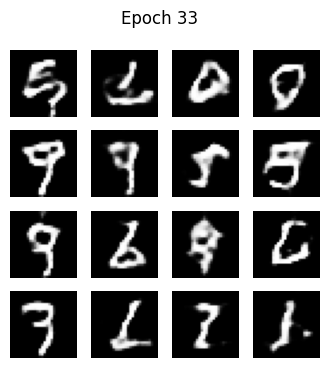

Epoch 34, Gen Loss: 1.1302, Disc Loss: 1.1341


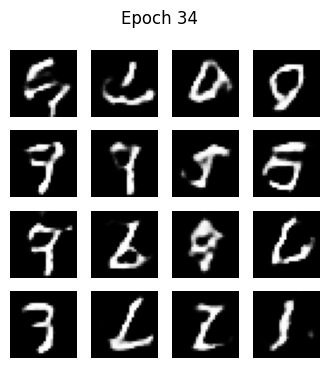

Epoch 35, Gen Loss: 0.9744, Disc Loss: 1.1866


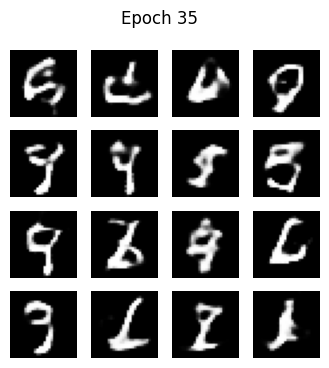

Epoch 36, Gen Loss: 0.9295, Disc Loss: 1.1946


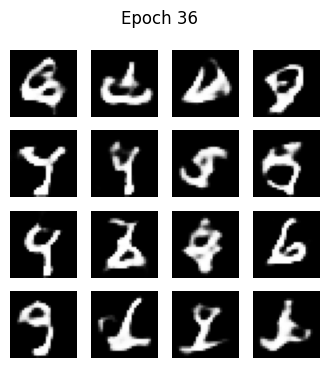

Epoch 37, Gen Loss: 0.9910, Disc Loss: 1.1632


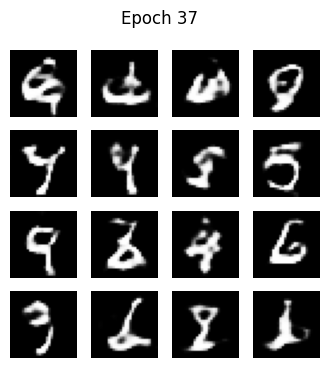

Epoch 38, Gen Loss: 1.0209, Disc Loss: 1.1671


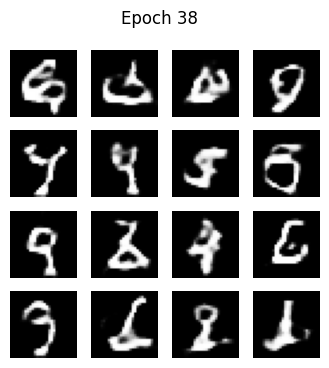

Epoch 39, Gen Loss: 1.0304, Disc Loss: 1.0867


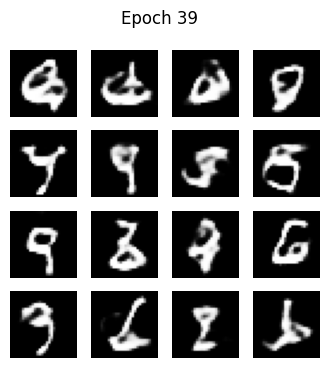

Epoch 40, Gen Loss: 0.8572, Disc Loss: 1.3059


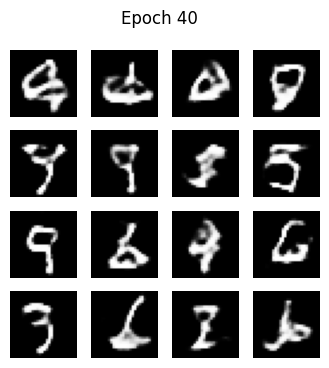

Epoch 41, Gen Loss: 0.9880, Disc Loss: 1.1850


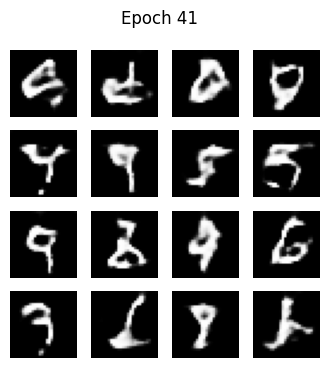

Epoch 42, Gen Loss: 1.0259, Disc Loss: 1.1481


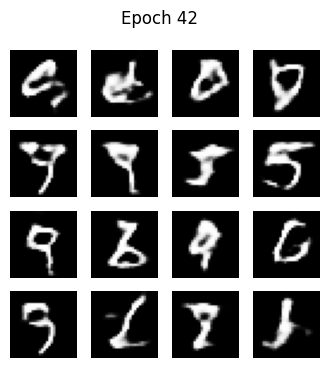

Epoch 43, Gen Loss: 1.0913, Disc Loss: 1.1325


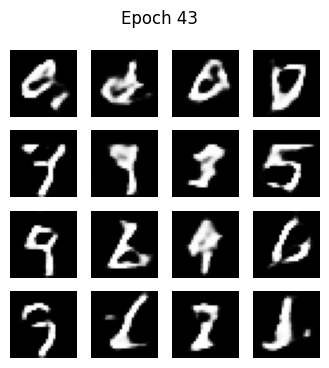

Epoch 44, Gen Loss: 0.9048, Disc Loss: 1.3203


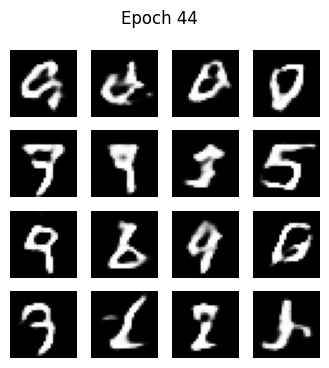

Epoch 45, Gen Loss: 0.9769, Disc Loss: 1.0823


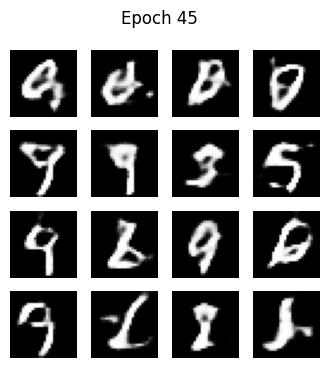

Epoch 46, Gen Loss: 0.9268, Disc Loss: 1.2168


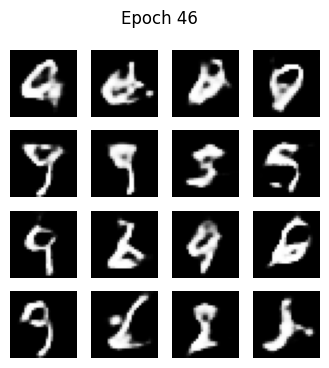

Epoch 47, Gen Loss: 0.9337, Disc Loss: 1.2838


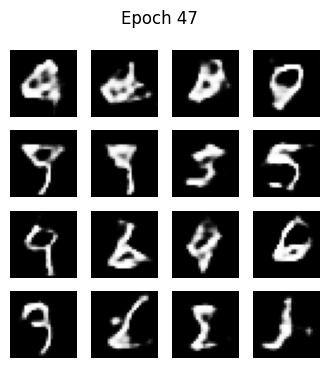

Epoch 48, Gen Loss: 0.9799, Disc Loss: 1.1223


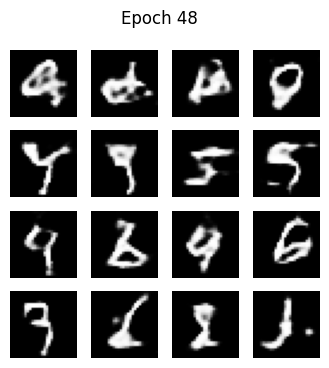

Epoch 49, Gen Loss: 0.9361, Disc Loss: 1.1688


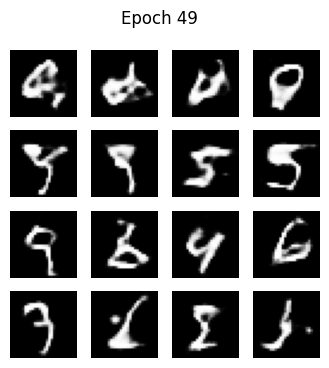

Epoch 50, Gen Loss: 1.0026, Disc Loss: 1.2700


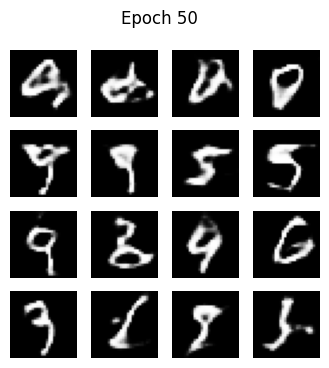

In [ ]:
#Run training
# ==============================
train(train_dataset, EPOCHS)